# Reação reversível A ⇌ C — Notebook 
**Objetivo:** resolver numericamente e plotar as concentrações temporais para a reação reversível simples
$$\mathrm{A} \xrightleftharpoons[k_{-1}]{k_{1}} \mathrm{C},$$
onde $k_1$ é a constante direta (A → C) e $k_{-1}$ é a constante inversa (C → A).
---


## Introdução teórica 

Consideramos a reação elementar reversível
$$
\mathrm{A} \xrightleftharpoons[k_{-1}]{k_{1}} \mathrm{C},
$$
com constantes de velocidade $k_1$ (direta) e $k_{-1}$ (inversa). Para passos unimoleculares elementares, as velocidades são proporcionais às concentrações das espécies reativas, e as equações diferenciais que governam o sistema são:
$$
\frac{d[A]}{dt} = -k_1\,[A] + k_{-1}\,[C],
$$
$$
\frac{d[C]}{dt} = +k_1\,[A] - k_{-1}\,[C].
$$

### Interpretação física e equilíbrio
- A soma $[A] + [C]$ é conservada num sistema fechado sem outras reações ($[A]+[C]=[A]_0+[C]_0$).
- Em equilíbrio dinâmico ($t\to\infty$) as velocidades direta e inversa se igualam: $k_1[A]_{\text{eq}} = k_{-1}[C]_{\text{eq}}$, o que define a constante de equilíbrio
$$
K_{\mathrm{eq}} = \frac{[C]_{\text{eq}}}{[A]_{\text{eq}}} = \frac{k_1}{k_{-1}}.
$$
- O sistema relaxa para o equilíbrio com uma taxa característica $\lambda = k_1 + k_{-1}$ (a matriz do sistema tem autovalores 0 e $-(k_1+k_{-1})$), ou seja, a componente de diferença $[A]-[A]_{\text{eq}}$ decai exponencialmente com taxa $\lambda$.


## Uso
Edite a célula de parâmetros e execute as células. O notebook plota apenas as curvas numéricas obtidas com `odeint`.

In [83]:
# Imports e definição das EDOs
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def edos(concs, t, k1, k_minus1):
    A, C = concs
    dAdt = -k1 * A + k_minus1 * C
    dCdt =  k1 * A - k_minus1 * C
    return [dAdt, dCdt]


In [84]:
# Parâmetros ajustáveis (altere aqui)
k1 = 0.8         # constante direta A -> C (s^-1)
k_minus1 = 0.2   # constante inversa C -> A (s^-1)
A0 = 1.0         # concentração inicial de A (mol·L^-1)
C0 = 0         # concentração inicial de C (mol·L^-1)
t_max = 10.0     # tempo máximo para integração (s)
n_points = 500   # número de pontos no tempo

t = np.linspace(0, t_max, n_points)
y0 = [A0, C0]

# Resolução numérica
sol = odeint(edos, y0, t, args=(k1, k_minus1))
A_t, C_t = sol.T


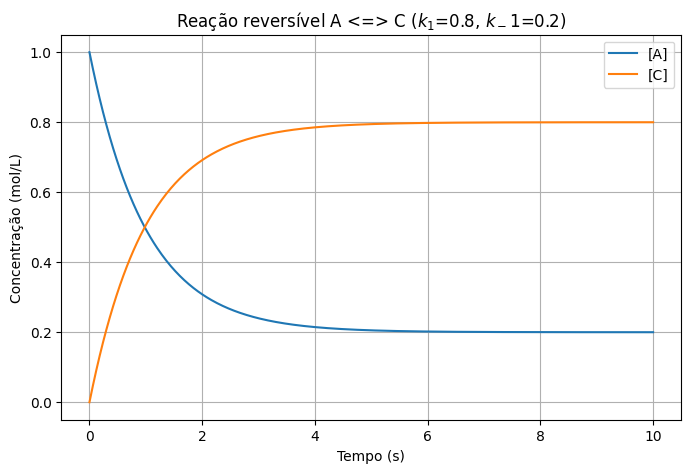

Constante de equilíbrio K_eq = k1/k_-1 = 4.0000
[A] = 0.20000 mol/L; [C] = 0.80000 mol/L


In [85]:
# Plot da solução numérica
plt.figure(figsize=(8,5))
plt.plot(t, A_t, label='[A]')
plt.plot(t, C_t, label='[C]')
plt.xlabel('Tempo (s)')
plt.ylabel('Concentração (mol/L)')
plt.title(f'Reação reversível A <=> C ($k_1$={k1}, $k_{-1}$={k_minus1})')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo de equilíbrio e impressão de resultados
A_eq = (A0 + C0) * (k_minus1 / (k1 + k_minus1))
C_eq = (A0 + C0) * (k1 / (k1 + k_minus1))
print(f"Constante de equilíbrio K_eq = k1/k_-1 = {k1/k_minus1:.4f}")
print(f"[A] = {A_eq:.5f} mol/L; [C] = {C_eq:.5f} mol/L")
